Archivos en template: ['pattern.png']
Archivos en images: ['COCA-COLA-LOGO.jpg', 'coca_logo_1.png', 'coca_logo_2.png', 'coca_multi.png', 'coca_retro_1.png', 'coca_retro_2.png', 'logo_1.png']
Tamaño template (h,w): (175, 400)


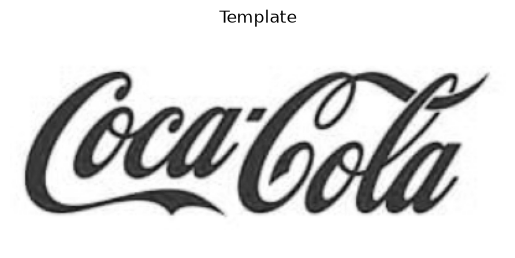

In [15]:
import cv2 as cv
import matplotlib.pyplot as plt
import os
import numpy as np

TEMPLATE_PATH = "template/pattern.png" 
IMAGES_PATH = "images"

print("Archivos en template:", os.listdir(os.path.dirname(TEMPLATE_PATH)))
print("Archivos en images:", os.listdir(IMAGES_PATH))

template = cv.imread(TEMPLATE_PATH, cv.IMREAD_GRAYSCALE)
print("Tamaño template (h,w):", template.shape)

plt.imshow(template, cmap='gray')
plt.title("Template")
plt.axis('off')
plt.show()

Tamaño imagen (h,w): (493, 715)
Tamaño template (h,w): (175, 400)


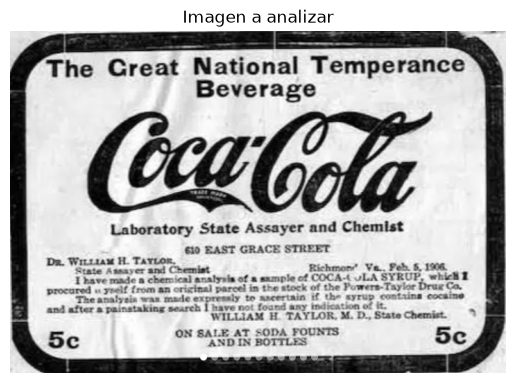

In [16]:
IMG_PATH = os.path.join(IMAGES_PATH, "coca_retro_1.png")
img = cv.imread(IMG_PATH)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

print("Tamaño imagen (h,w):", img_gray.shape)
print("Tamaño template (h,w):", template.shape)

plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Imagen a analizar")
plt.axis('off')
plt.show()

min_val: -0.30091533064842224 max_val: 0.2711469531059265
max_loc: (108, 104)


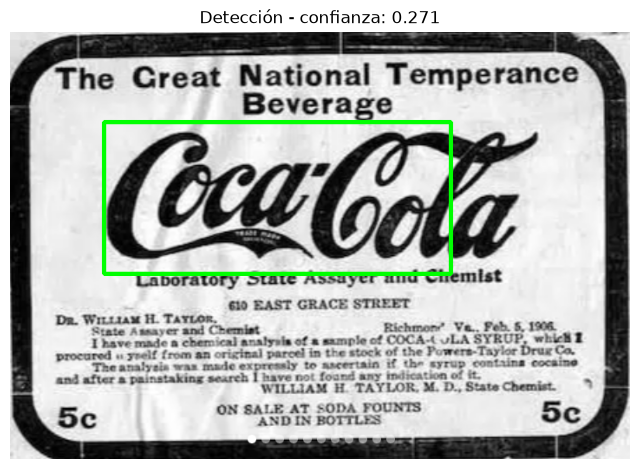

In [17]:
method = cv.TM_CCOEFF_NORMED

res = cv.matchTemplate(img_gray, template, method)

min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)
print("min_val:", min_val, "max_val:", max_val)
print("max_loc:", max_loc)

# Dibujamos el bounding box del mejor match
h, w = template.shape
top_left = max_loc
bottom_right = (top_left[0] + w, top_left[1] + h)

img_salida = img.copy()
cv.rectangle(img_salida, top_left, bottom_right, (0, 255, 0), 3)

plt.figure(figsize=(8,6))
plt.imshow(cv.cvtColor(img_salida, cv.COLOR_BGR2RGB))
plt.title(f"Detección - confianza: {max_val:.3f}")
plt.axis('off')
plt.show()

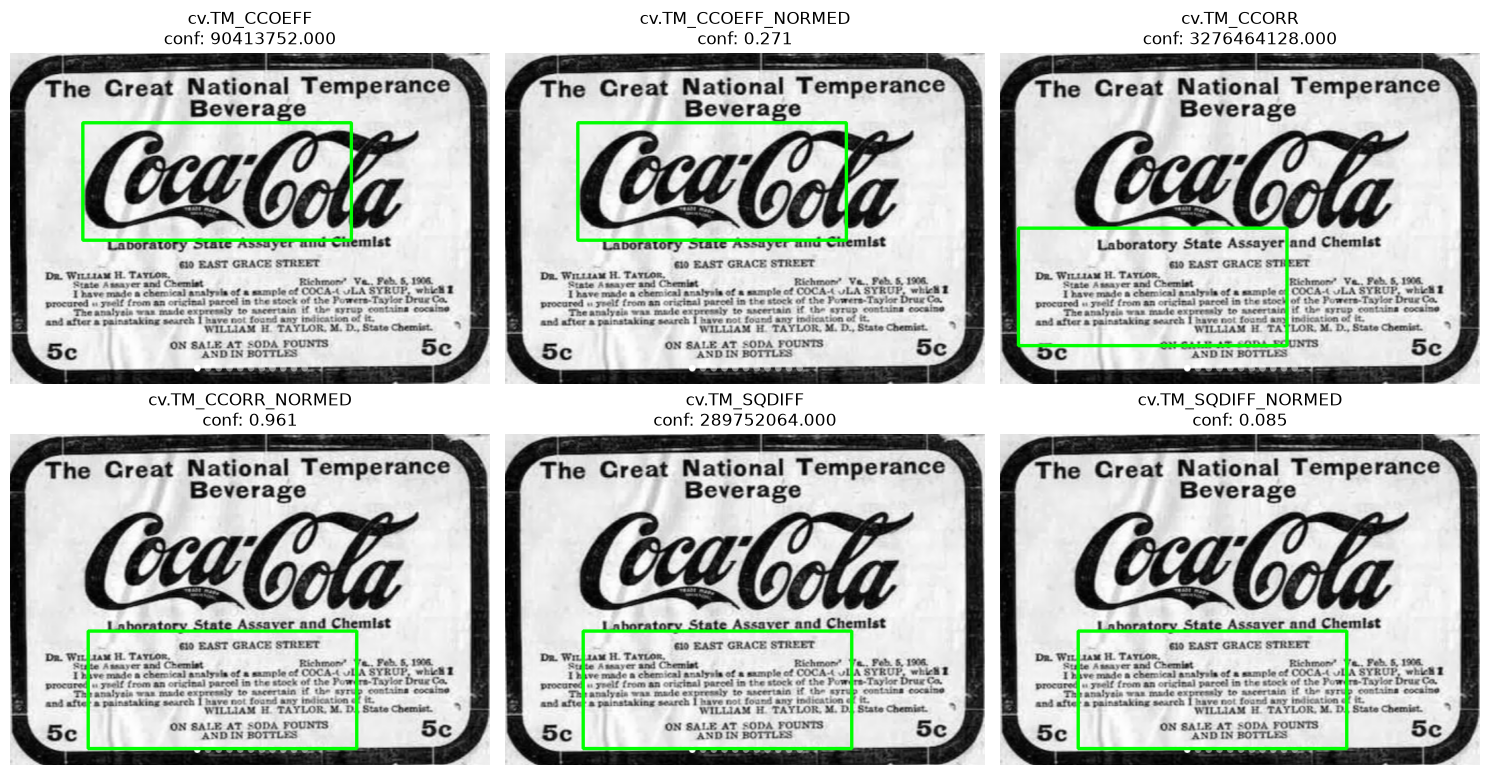

In [18]:
methods = ['cv.TM_CCOEFF', 'cv.TM_CCOEFF_NORMED', 'cv.TM_CCORR',
           'cv.TM_CCORR_NORMED', 'cv.TM_SQDIFF', 'cv.TM_SQDIFF_NORMED']

h, w = template.shape

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for idx, meth in enumerate(methods):
    method = eval(meth)
    res = cv.matchTemplate(img_gray, template, method)
    min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

    if method in [cv.TM_SQDIFF, cv.TM_SQDIFF_NORMED]:
        top_left = min_loc
        confianza = min_val
    else:
        top_left = max_loc
        confianza = max_val

    bottom_right = (top_left[0] + w, top_left[1] + h)
    img_salida = img.copy()
    cv.rectangle(img_salida, top_left, bottom_right, (0, 255, 0), 3)

    axes[idx].imshow(cv.cvtColor(img_salida, cv.COLOR_BGR2RGB))
    axes[idx].set_title(f"{meth}\nconf: {confianza:.3f}")
    axes[idx].axis('off')

plt.tight_layout()
plt.show()
